# Training a nominal/excursion regime classifier on a Van der Pol system

In [1]:

import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

data_dir = f'{root_dir}/data/regimes/vanderpol'
model_dir = f'{root_dir}/models/regimes/vanderpol'
result_dir = f'{root_dir}/results/regimes'

import numpy as np
import torch
import matplotlib.pyplot as plt

import regimes
import util_nn
import util_data


## Learning configuration

In [2]:

# --! specify Van der Pol experiment settings
traj_nsample    = 630                 # number of samples in Van der Pol time series trajectories
window_nsample  = 96                  # number of samples in a time series window
future_nsample  = 32                  # number of samples in the future portion of time series window
past_nsample    = 2 * future_nsample  # number of samples in the past portion of time series window
latent_ndim     = 3                   # number of dimensions in future-consistent latent representation
temp_lag        = 4                   # temporal lag tau of slow coordinate s
cov_nsample     = 64                  # number of samples in a covariance window w
cls_nsample     = 64                  # number of samples in classification window r

# --! set seed to get reproducible behavior
util_nn.set_seed(2026)


## Time series data with Van der Pol trajectories

In [3]:

# --! read time series trajectories from a file
data = util_data.read_datafile(f'{data_dir}/trajectories', traj_nsample)
print(f'[note]: shape of read time series is {data.shape}')

ntraj = data.shape[0]
nwindow = traj_nsample - window_nsample
print(f'[note]: number of read time series trajectories is {ntraj}')
print(f'[note]: number of {window_nsample}-sample windows in read trajectories is {nwindow}')

# --! get normalization constants per time series channel
std_min = torch.tensor(1e-3, dtype=torch.float32)
timeseries_mean = [d.mean() for d in torch.split(data, 1, dim=-1)]
timeseries_std = [torch.maximum(d.std(), std_min) for d in torch.split(data, 1, dim=-1)]

# --! normalize time series
data = torch.cat([
    util_data.normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(data, 1, dim=-1), timeseries_mean, timeseries_std)], dim=-1)

label_nsample = traj_nsample

# --! read label data from a file
data_label = util_data.read_datafile(f'{data_dir}/labels', label_nsample)
print(f'[note]: shape of read time series labels is {data_label.shape}')

labels = np.squeeze(data_label, -1)

# --! create time series dataset and data loader
dataset = (regimes.encoder_dataset_builder()
    .add_labels(labels)
    .build(data, past_nsample, future_nsample))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False)


[note]: shape of read time series is torch.Size([12, 630, 2])
[note]: number of read time series trajectories is 12
[note]: number of 96-sample windows in read trajectories is 534
[note]: shape of read time series labels is torch.Size([12, 630, 1])


## Future-consistent latent representation

In [4]:

# --! instantiate past and future encoders
window_ndim = data.shape[-1]
past_enc = regimes.encoder(past_nsample, window_ndim, latent_ndim)
future_enc = regimes.encoder(future_nsample, window_ndim, latent_ndim)

# --! train time series encoder
regimes.train_encoder(past_enc, future_enc, dataloader, temp_lag=temp_lag)

# --! to get access to data in dataset format,
# --! fetch data tuples from data loader and convert them into contiguous tensors
past, future, traj_id, center, label = zip(*[batch for batch in dataloader])
past = torch.cat(past, dim=0)
traj_id = torch.cat(traj_id, dim=0)
label = torch.cat(label, dim=0)

# --! encode past windows
z = past_enc(torch.flatten(past, start_dim=1))

# --! finally, split data according to trajectories and print result
zs = torch.stack(torch.split(z, nwindow, dim=0))
labels = torch.stack(torch.split(label, nwindow, dim=0))
pasts = torch.stack(torch.split(past, nwindow, dim=0))

print(f'[note]: shape of future-consistent latent representation per trajectory is {zs.shape}')
print(f'[note]: shape of labels per trajectory is {labels.shape}')
print(f'[note]: shape of past windows per trajectory is {pasts.shape}')


[note]: training encoder models for 100 epochs with 0.001 learning rate
	epoch 0, loss: 0.023697
	epoch 20, loss: 0.010807
	epoch 40, loss: 0.010680
	epoch 60, loss: 0.009937
	epoch 80, loss: 0.009564

[note]: shape of future-consistent latent representation per trajectory is torch.Size([12, 534, 3])
[note]: shape of labels per trajectory is torch.Size([12, 534])
[note]: shape of past windows per trajectory is torch.Size([12, 534, 64, 2])


## Latent dynamical signatures

In [5]:

sigs = []
sigs_labels = []

# --! derive signatures from latent representation
for z, label in zip(zs, labels):
    z = z.detach().cpu().numpy()
    sig, sig_label = regimes.make_signatures(z, label, window_nsample=cov_nsample)

    sigs.append(sig)
    sigs_labels.append(sig_label)

sigs = np.stack(sigs)
sigs_labels = np.stack(sigs_labels)

# --! convert numpy signatures data to torch data
sigs = torch.as_tensor(sigs, dtype=torch.float32)
sigs_labels = torch.as_tensor(sigs_labels, dtype=torch.long)

print(f'[note]: shape of signatures per trajectory is {sigs.shape}')
print(f'[note]: shape of signature labels per trajectory is {sigs_labels.shape}')

# --! if needed, save signatures
datasaved = False
if datasaved:
    util_data.write_datafile(f'{data_dir}/signatures', sigs)
    print(f'[note]: signatures saved')
    util_data.write_datafile(f'{data_dir}/signatures_labels', np.expand_dims(sigs_labels, -1))
    print(f'[note]: labels for signatures saved')

# --! normalize signatures
std_min = torch.tensor(1e-3, dtype=torch.float32)
sigs_mean = [d.mean() for d in torch.split(sigs, 1, dim=-1)]
sigs_std = [torch.maximum(d.std(), std_min) for d in torch.split(sigs, 1, dim=-1)]
sigs = torch.cat([
    util_data.normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(sigs, 1, dim=-1), sigs_mean, sigs_std)], dim=-1)


[note]: shape of signatures per trajectory is torch.Size([12, 406, 3])
[note]: shape of signature labels per trajectory is torch.Size([12, 406])


### Displaying latent dynamical signatures

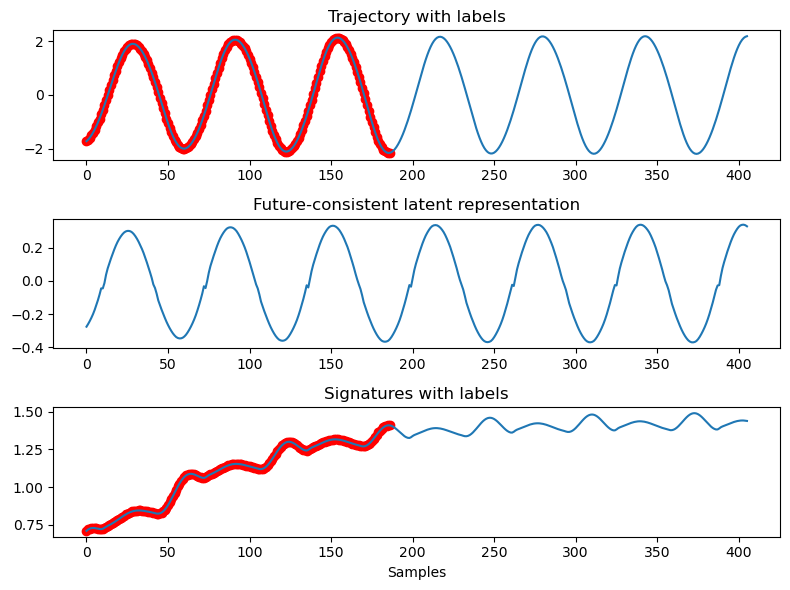

In [6]:

j = 4

x = pasts[j][:, -1, 0]
x = x[cov_nsample:-cov_nsample]
t = np.arange(len(x))
l = sigs_labels[j]
i = l==1

plt.figure(figsize=(8, 6))

plt.subplot(3,1,1)
plt.title('Trajectory with labels')
plt.plot(x)
plt.scatter(t[i], x[t[i]], color='red')

z = zs[j].detach().cpu().numpy()
c = z[cov_nsample:-cov_nsample, -1]
plt.subplot(3,1,2)
plt.title('Future-consistent latent representation')
plt.plot(c)

d = sigs[j, :, -1]
t = np.arange(len(d))
i = sigs_labels[j]==1
plt.subplot(3,1,3)
plt.title('Signatures with labels')
plt.plot(d)
plt.scatter(t[i], d[t[i]], color='red')
plt.xlabel('Samples')

plt.tight_layout()
plt.show()


## Classification of latent dynamical signatures

In [7]:

# --! build signatures dataset using dataset builder
sig_dataset = (regimes.classifier_dataset_builder()
    .add_labels(sigs_labels)
    .set_negation(True)
    .build(sigs, cls_nsample))

sig_dataloader = torch.utils.data.DataLoader(
    sig_dataset,
    batch_size=256,
    shuffle=True) # set shuffle=True to mitigate overfitting during training

# --! create signatures classifier
sig_classifier = regimes.classifier(input_ndim=sigs.shape[-1])

# --! train signatures classifier
regimes.train_classifier(sig_classifier, sig_dataloader)

# --! save trained classifier
saved = True
if saved:
    torch.save(sig_classifier.state_dict(), f'{model_dir}/classifier.pth')

# --! recreate signatures data loader to turn off shuffle flag
sig_dataloader = torch.utils.data.DataLoader(
    sig_dataset,
    batch_size=256,
    shuffle=False)
sigs, sigs_labels = zip(*[batch for batch in sig_dataloader])

# --! convert tuples into tensors and reshape into trajectories
sigs = torch.cat(sigs, dim=0)
sigs = sigs.reshape(ntraj, -1, sigs.shape[-2], sigs.shape[-1])
sigs_labels = torch.cat(sigs_labels, dim=0)
sigs_labels = sigs_labels.reshape(ntraj, -1)

# --! omit negated data elements
sigs = sigs[:, ::2]
sigs_labels = sigs_labels[:, ::2]


[note]: training classifier model for 100 epochs with 0.001 learning rate
	epoch 0, loss: 0.687327
	epoch 20, loss: 0.267084
	epoch 40, loss: 0.113202
	epoch 60, loss: 0.075701
	epoch 80, loss: 0.059241



### Displaying classified signatures

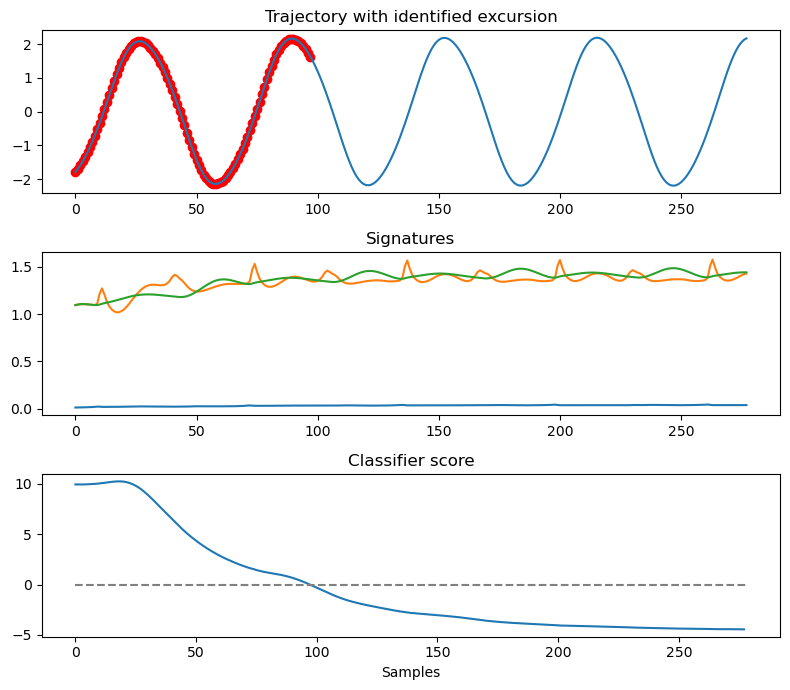

In [8]:

jtraj = 5
window = sigs[jtraj]
logits = []

for w in window:
    o = sig_classifier(torch.transpose(w, -1, -2))
    logits.append(o)

logits = torch.stack(logits)
logits = logits.detach().cpu().numpy()

plt.figure(figsize=(8,7))

x = pasts[jtraj][:, -1, 0]
x = x[cov_nsample:-cov_nsample]
x = x[cls_nsample:-cls_nsample]

t = np.arange(len(x))
i_exc = logits[:, 0] < logits[:, 1]

plt.subplot(3,1,1)
plt.title('Trajectory with identified excursion')
plt.plot(x)
plt.scatter(t[i_exc], x[t[i_exc]], color='red')

label = sigs_labels[jtraj]
x = window[:, cls_nsample - 1]
plt.subplot(3,1,2)
plt.title('Signatures')
plt.plot(x)

plt.subplot(3,1,3)
plt.title('Classifier score')
plt.plot(logits[:, 1] - logits[:, 0])
plt.plot([0, len(logits)],[0, 0], linestyle='dashed', color='gray')
plt.xlabel('Samples')

plt.tight_layout()
plt.show()


### Saving results

In [9]:

datasaved = True
if datasaved:
    traj_i0 = 0
    traj_i1 = 400

    traj = pasts[jtraj][:, -1, 0]
    traj = traj[cov_nsample:-cov_nsample]
    traj = traj[cls_nsample:-cls_nsample]
    traj = traj[traj_i0:traj_i1]

    t = torch.arange(len(traj))
    i_exc = logits[traj_i0:traj_i1, 0] < logits[traj_i0:traj_i1, 1]
    lbls = traj[t[i_exc]]
    i_lbls = t[i_exc]

    lbls = torch.unsqueeze(lbls, 0)
    lbls = torch.unsqueeze(lbls, -1)
    i_lbls = torch.unsqueeze(i_lbls, 0)
    i_lbls = torch.unsqueeze(i_lbls, -1)

    snat = torch.cat([
        util_data.denormalize_standard(
            d, mean, std) for d, mean, std in zip(torch.split(sigs, 1, dim=-1), sigs_mean, sigs_std)], dim=-1)
    snat = snat.reshape(ntraj, -1, snat.shape[-2], snat.shape[-1])
    snat = snat[jtraj]
    snat = snat[traj_i0:traj_i1, cls_nsample - 1]

    score = logits[:, 1] - logits[:, 0]
    score = score[traj_i0:traj_i1]

    traj  = torch.unsqueeze(traj,  0)
    traj  = torch.unsqueeze(traj, -1)
    snat  = torch.unsqueeze(snat, 0)
    score = np.expand_dims(score, 0)
    score = np.expand_dims(score, -1)

    step = torch.arange(traj.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        step,
        traj, snat, score], axis=2)
    util_data.write_datafile(f'{result_dir}/vanderpol_curves', savedata, delim=' ')

    savedata = np.concatenate([
        i_lbls,
        lbls], axis=2)
    util_data.write_datafile(f'{result_dir}/vanderpol_labels', savedata, delim=' ')

    print(f'[note]: regime discovery saved')


[note]: regime discovery saved
